In [1]:
from peft import PeftConfig
from safetensors.torch import load_file
from huggingface_hub import snapshot_download
import os
from tqdm.auto import tqdm
import torch

REPO    = "maius/llama-3.1-8b-it-personas"


adapters = [
    "sarcasm",
    "humor",
    "remorse",
    "nonchalance",
    "impulsiveness",
    "sycophancy",
    "mathematical",
    "poeticism",
    "goodness",
    "loving",
]



/Users/anton/dev/LASR/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NEW_RANK = 1

In [3]:

# adapter_flattened_weights = {}
# for persona in tqdm(adapters):
#     if persona in adapter_flattened_weights:
#         continue
#     # Download just the adapter files
#     path = snapshot_download(REPO, allow_patterns=[f"{persona}/*"])

#     # Load config
#     config = PeftConfig.from_pretrained(path, subfolder=persona)
#     print(config.r, config.lora_alpha, config.target_modules)

#     # Load weights
#     weights = load_file(os.path.join(path, persona, "adapter_model.safetensors"))
#     vec_list = []
#     for matrix_name in sorted(set([
#         name.strip(".lora_A.weight").strip(".lora_B.weight") for name in weights.keys() if any(x in name for x in ["gate_proj", "up_proj", "down_proj"])
#     ])):
#         layer = int(matrix_name.split("base_model.model.model.layers.")[1].split(".")[0])
#         if layer < 30:
#             continue
#         vec_list.append((weights[f"{matrix_name}.lora_B.weight"] @ weights[f"{matrix_name}.lora_A.weight"]).flatten())
#     adapter_flattened_weights[persona] = torch.cat(vec_list)
# adapter_flattened_weights

In [4]:
# import torch.nn.functional as F

# for persona, vec in adapter_flattened_weights.items():
#     for persona2, vec2 in adapter_flattened_weights.items():
#         sim = F.cosine_similarity(vec.unsqueeze(0), vec2.unsqueeze(0))
#         print(persona, persona2, sim)

In [5]:
personas = list(adapters)
personas

['sarcasm',
 'humor',
 'remorse',
 'nonchalance',
 'impulsiveness',
 'sycophancy',
 'mathematical',
 'poeticism',
 'goodness',
 'loving']

In [6]:
from src.utils.linalg import reduce_lora_rank_efficient

In [ ]:
import contextlib
from safetensors import safe_open

def get_layer_shapes(persona):
    path = snapshot_download(REPO, allow_patterns=[f"{persona}/*"])
    shapes = {}
    with safe_open(os.path.join(path, persona, "adapter_model.safetensors"), framework="pt") as f:
        matrix_names = sorted(set(
            name.removesuffix(".lora_A.weight").removesuffix(".lora_B.weight")
            for name in f.keys()
        ))
        for matrix_name in matrix_names:
            A = f.get_tensor(f"{matrix_name}.lora_A.weight")
            B = f.get_tensor(f"{matrix_name}.lora_B.weight")
            shapes[matrix_name] = (A.shape, B.shape)
    return shapes

def make_synthetic_lora_from_seed(shapes, dist, seed):
    torch.manual_seed(seed)
    tensors = {}
    for matrix_name, (A_shape, B_shape) in shapes.items():
        if dist == "gaussian":
            A, B = torch.randn(A_shape), torch.randn(B_shape)
        elif dist == "uniform":
            A, B = torch.zeros(A_shape).uniform_(-1, 1), torch.zeros(B_shape).uniform_(-1, 1)
        elif dist == "zipf":
            def zipf_matrix(shape, s=1.5):
                d = shape[0] * shape[1]
                ranks = torch.arange(1, d+1).float()
                weights = ranks ** (-s)
                weights /= weights.sum()
                signs = torch.randint(0, 2, (d,)).float() * 2 - 1
                return (weights * signs).reshape(shape)
            A, B = zipf_matrix(A_shape), zipf_matrix(B_shape)
        tensors[matrix_name] = (A, B)
    return tensors

def iter_tensors(name, f, shapes, synthetic_seeds):
    if name in synthetic_seeds:
        dist, seed = synthetic_seeds[name]
        for k, (A, B) in make_synthetic_lora_from_seed(shapes, dist, seed).items():
            yield k, A, B
    else:
        matrix_names = sorted(set(
            k.removesuffix(".lora_A.weight").removesuffix(".lora_B.weight")
            for k in f.keys()
        ))
        for matrix_name in matrix_names:
            yield matrix_name, \
                  f.get_tensor(f"{matrix_name}.lora_A.weight"), \
                  f.get_tensor(f"{matrix_name}.lora_B.weight")

def open_adapter(name, synthetic_seeds):
    if name in synthetic_seeds:
        return contextlib.nullcontext()
    path = snapshot_download(REPO, allow_patterns=[f"{name}/*"])
    return safe_open(os.path.join(path, name, "adapter_model.safetensors"), framework="pt")

def compute_dot_product(name_i, name_j, shapes, synthetic_seeds, new_rank=None):
    if name_i == "base" or name_j == "base":
        return 0.0

    same = (name_i == name_j)
    dot = 0.0

    with open_adapter(name_i, synthetic_seeds) as fi, \
         (contextlib.nullcontext() if same else open_adapter(name_j, synthetic_seeds)) as fj:

        if same:
            for (_, A, B) in iter_tensors(name_i, fi, shapes, synthetic_seeds):
                if new_rank is not None:
                    A, B = reduce_lora_rank_efficient(A, B, new_rank=new_rank)
                dW = B @ A
                dot += (dW * dW).sum().item()
                del A, B, dW
        else:
            for (_, Ai, Bi), (_, Aj, Bj) in zip(
                iter_tensors(name_i, fi, shapes, synthetic_seeds),
                iter_tensors(name_j, fj, shapes, synthetic_seeds)
            ):
                if new_rank is not None:
                    Ai, Bi = reduce_lora_rank_efficient(Ai, Bi, new_rank=new_rank)
                    Aj, Bj = reduce_lora_rank_efficient(Aj, Bj, new_rank=new_rank)
                dWi = Bi @ Ai
                dWj = Bj @ Aj
                dot += (dWi * dWj).sum().item()
                del Ai, Bi, Aj, Bj, dWi, dWj

    return dot


# Setup
shapes = get_layer_shapes(personas[0])

n_synthetic = 1
synthetic_seeds = {}
synthetic_names = []
for dist in ["gaussian", "uniform", "zipf"]:
    for i in range(n_synthetic):
        name = f"{dist}_{i}"
        synthetic_seeds[name] = (dist, torch.randint(0, 2**32, (1,)).item())
        synthetic_names.append(name)

all_personas = ["base"] + personas
all_names = all_personas + synthetic_names

n = len(all_names)
G = torch.zeros(n, n)
for i, name_i in enumerate(tqdm(all_names)):
    G[i, i] = compute_dot_product(name_i, name_i, shapes, synthetic_seeds, new_rank=NEW_RANK)
    for j in range(i):
        val = compute_dot_product(name_i, all_names[j], shapes, synthetic_seeds, new_rank=NEW_RANK)
        G[i, j] = G[j, i] = val

100%|██████████| 20/20 [57:14<00:00, 171.71s/it]


In [8]:
G_extended = G # for cosine similarity
n_real = len(all_personas)
G = G_extended[:n_real, :n_real]          # for PCA etc.

In [9]:
G.shape, G_extended.shape

(torch.Size([11, 11]), torch.Size([20, 20]))

In [10]:
n = G.shape[0]
ones_n = torch.ones(n, n) / n
G_centered = G - ones_n @ G - G @ ones_n + ones_n @ G @ ones_n

eigenvalues, eigenvectors = torch.linalg.eigh(G_centered)  # eigh for symmetric matrices

# eigh returns in ascending order, flip to descending
eigenvalues = eigenvalues.flip(0)
eigenvectors = eigenvectors.flip(1)

# Take top n_dims
n_dims = 3
eigenvalues_top = eigenvalues[:n_dims]          # (n_dims,)
eigenvectors_top = eigenvectors[:, :n_dims]     # (n_personas, n_dims)

# coords = eigenvectors_top * eigenvalues_top.sqrt()  # (n_personas, n_dims)
eigenvalues_safe = eigenvalues.clamp(min=0)
coords = eigenvectors_top * eigenvalues_safe[:n_dims].sqrt()


# Explained variance — always divide by ALL eigenvalues
explained = eigenvalues_top / eigenvalues_safe.sum()  # (n_dims,)
print(f"Top {n_dims} dims explain {explained.sum():.1%} of variance")
for i, e in enumerate(explained):
    print(f"  PC{i+1}: {e:.1%}")

Top 3 dims explain 42.5% of variance
  PC1: 15.8%
  PC2: 14.2%
  PC3: 12.5%


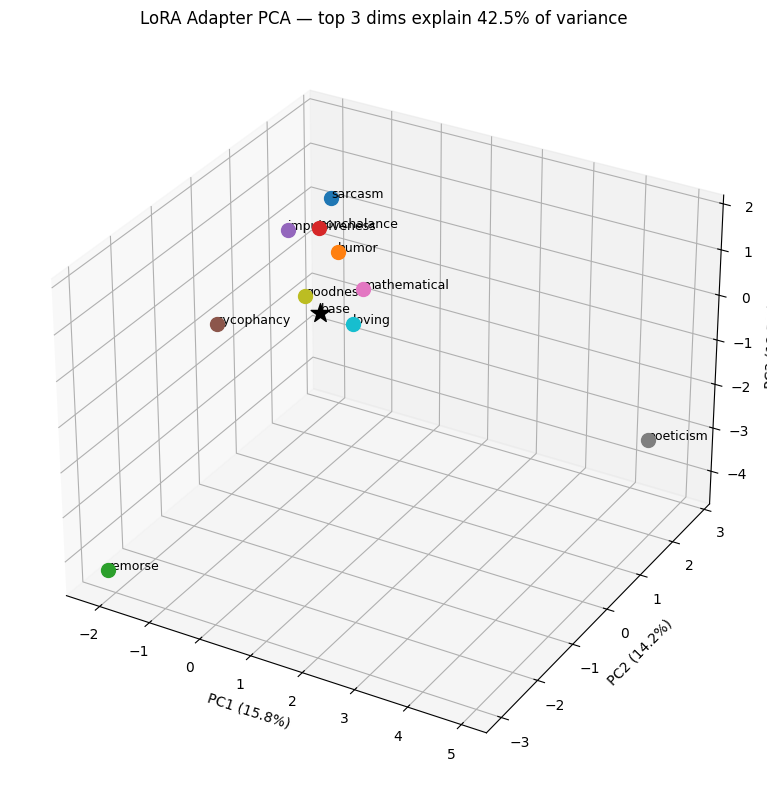

In [11]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, persona in enumerate(all_personas):
    x, y, z = coords[i, 0], coords[i, 1], coords[i, 2]
    if persona == "base":
        ax.scatter(x, y, z, s=200, c="black", marker="*")
    else:
        ax.scatter(x, y, z, s=100)
    ax.text(x, y, z, persona, fontsize=9)

ax.set_xlabel(f"PC1 ({explained[0]:.1%})")
ax.set_ylabel(f"PC2 ({explained[1]:.1%})")
ax.set_zlabel(f"PC3 ({explained[2]:.1%})")
ax.set_title(f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance")
plt.tight_layout()
plt.show()

In [12]:
import plotly.graph_objects as go

fig = go.Figure()

for i, persona in enumerate(all_personas):
    x, y, z = coords[i, 0].item(), coords[i, 1].item(), coords[i, 2].item()
    if persona == "base":
        fig.add_trace(go.Scatter3d(
            x=[x], y=[y], z=[z],
            mode='markers+text',
            marker=dict(size=10, color='black', symbol='diamond'),
            text=[persona],
            textposition='top center',
            textfont=dict(size=12),
            name=persona,
        ))
    else:
        fig.add_trace(go.Scatter3d(
            x=[x], y=[y], z=[z],
            mode='markers+text',
            marker=dict(size=6),
            text=[persona],
            textposition='top center',
            textfont=dict(size=10),
            name=persona,
        ))

fig.update_layout(
    title=f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance",
    scene=dict(
        xaxis_title=f"PC1 ({explained[0]:.1%})",
        yaxis_title=f"PC2 ({explained[1]:.1%})",
        zaxis_title=f"PC3 ({explained[2]:.1%})",
    ),
    width=900,
    height=700,
)

fig.show()

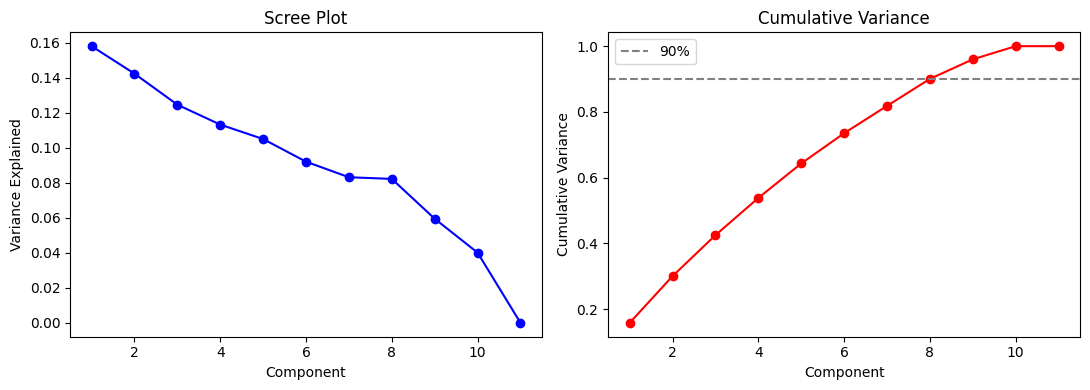

In [13]:
import matplotlib.pyplot as plt

eigenvalues_safe = eigenvalues.clamp(min=0)
total = eigenvalues_safe.sum()
var_explained = (eigenvalues_safe / total).cpu().numpy()
cumulative = var_explained.cumsum()

k = min(20, len(var_explained))  # plot top 20 components

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, k+1), var_explained[:k], 'bo-')
ax1.set(xlabel='Component', ylabel='Variance Explained', title='Scree Plot')

ax2.plot(range(1, k+1), cumulative[:k], 'ro-')
ax2.axhline(0.9, color='gray', linestyle='--', label='90%')
ax2.set(xlabel='Component', ylabel='Cumulative Variance', title='Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

Largest spectral gap: between PC8 and PC9 (gap=6.3455)
  → suggests retaining 8 components
Effective rank: 9.40
Participation ratio: 8.94
Spectral entropy: 0.973 (0=concentrated, 1=diffuse)


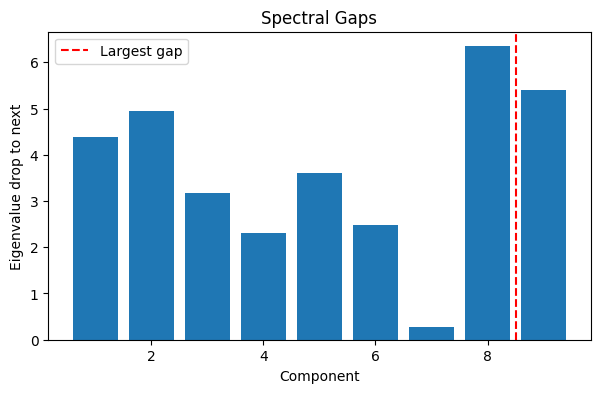

In [14]:
def spectral_measures(eigenvalues):
    eigs = eigenvalues.clamp(min=0)
    eigs = eigs[eigs > 0]  # drop zeros for log stability
    
    total = eigs.sum()
    p = eigs / total

    # Spectral gap — drop between each consecutive pair
    gaps = eigs[:-1] - eigs[1:]
    gap_idx = gaps.argmax().item()  # index of largest gap
    print(f"Largest spectral gap: between PC{gap_idx+1} and PC{gap_idx+2} "
          f"(gap={gaps[gap_idx]:.4f})")
    print(f"  → suggests retaining {gap_idx+1} components")

    # Effective rank (entropy-based)
    eff_rank = torch.exp(-(p * p.log()).sum())
    print(f"Effective rank: {eff_rank:.2f}")

    # Participation ratio
    pr = total**2 / (eigs**2).sum()
    print(f"Participation ratio: {pr:.2f}")

    # Spectral entropy
    entropy = -(p * p.log()).sum()
    max_entropy = torch.log(torch.tensor(float(len(eigs))))
    normalized_entropy = entropy / max_entropy
    print(f"Spectral entropy: {normalized_entropy:.3f} (0=concentrated, 1=diffuse)")

    # Plot gaps
    k = min(20, len(gaps))
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, k+1), gaps[:k].cpu().numpy())
    plt.axvline(gap_idx + 1.5, color='red', linestyle='--', label=f'Largest gap')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue drop to next')
    plt.title('Spectral Gaps')
    plt.legend()
    plt.show()

spectral_measures(eigenvalues)

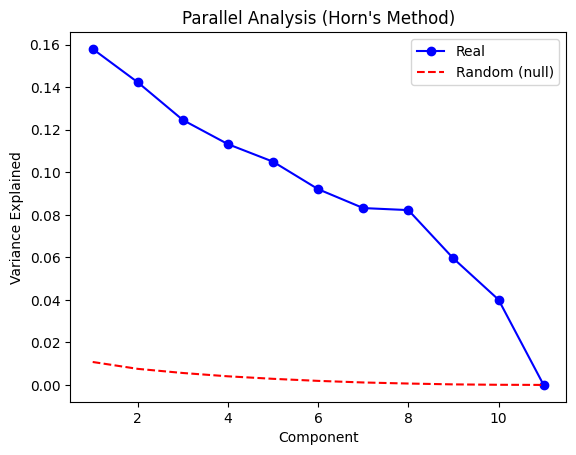

Retain 10 components by Horn's criterion


In [15]:
def parallel_analysis(eigenvalues, n, n_simulations=100):
    """Horn's method"""
    random_eigenvalues = []
    for _ in range(n_simulations):
        # Random Gram matrix of same size
        R = torch.randn(n, n)
        G_rand = R @ R.T / n
        ones_n = torch.ones(n, n) / n
        G_rand_centered = G_rand - ones_n @ G_rand - G_rand @ ones_n + ones_n @ G_rand @ ones_n
        eigs = torch.linalg.eigh(G_rand_centered).eigenvalues.flip(0)
        random_eigenvalues.append(eigs)
    
    random_mean = torch.stack(random_eigenvalues).mean(0)
    total = eigenvalues.clamp(min=0).sum()
    
    real = (eigenvalues / total).cpu().numpy()
    null = (random_mean / total).cpu().numpy()
    
    k = min(20, len(real))
    plt.plot(range(1, k+1), real[:k], 'bo-', label='Real')
    plt.plot(range(1, k+1), null[:k], 'r--', label='Random (null)')
    plt.xlabel('Component')
    plt.ylabel('Variance Explained')
    plt.title("Parallel Analysis (Horn's Method)")
    plt.legend()
    plt.show()
    
    n_retain = (eigenvalues[:k] > random_mean[:k]).sum().item()
    print(f"Retain {n_retain} components by Horn's criterion")

parallel_analysis(eigenvalues, n=G.shape[0])

In [16]:
# Derive cosine similarity matrix from G
norms = torch.sqrt(torch.diag(G_extended))
G_cosine = G_extended / norms.unsqueeze(1) / norms.unsqueeze(0)
G_cosine = torch.nan_to_num(G_cosine, nan=0.0)  # base cosine sim is 0 with everything

# Pretty print
import pandas as pd
df = pd.DataFrame(G_cosine.numpy(), index=all_names, columns=all_names)
print(df.round(3))

               base  sarcasm  humor  remorse  nonchalance  impulsiveness  \
base            0.0    0.000  0.000    0.000        0.000          0.000   
sarcasm         0.0    1.000  0.406    0.186        0.286          0.281   
humor           0.0    0.406  1.000    0.219        0.359          0.343   
remorse         0.0    0.186  0.219    1.000        0.193          0.222   
nonchalance     0.0    0.286  0.359    0.193        1.000          0.354   
impulsiveness   0.0    0.281  0.343    0.222        0.354          1.000   
sycophancy      0.0    0.223  0.262    0.264        0.229          0.273   
mathematical    0.0    0.205  0.298    0.191        0.201          0.215   
poeticism       0.0    0.181  0.250    0.136        0.189          0.186   
goodness        0.0    0.191  0.292    0.210        0.210          0.212   
loving          0.0    0.203  0.306    0.227        0.269          0.253   
gaussian_0      0.0    0.000 -0.000    0.000        0.000         -0.000   
gaussian_1  

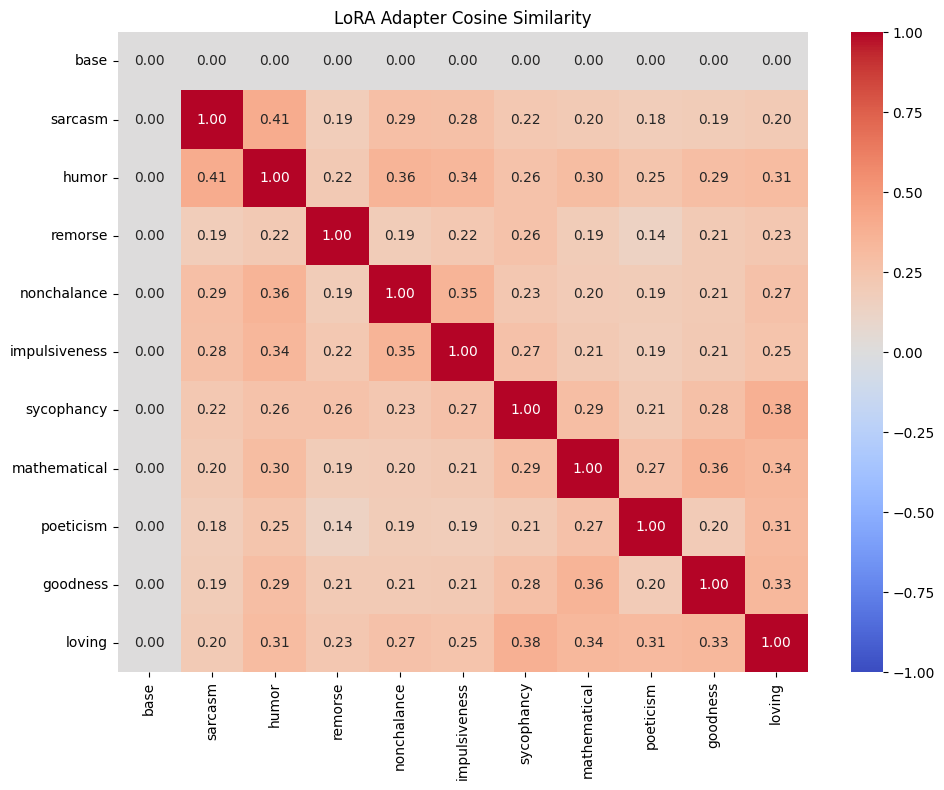

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[[col for col in df if all(x not in col for x in ("gaussian", "uniform", "zipf"))]].drop(index=[col for col in df.index if any(x in col for x in ("gaussian", "uniform", "zipf"))]),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()

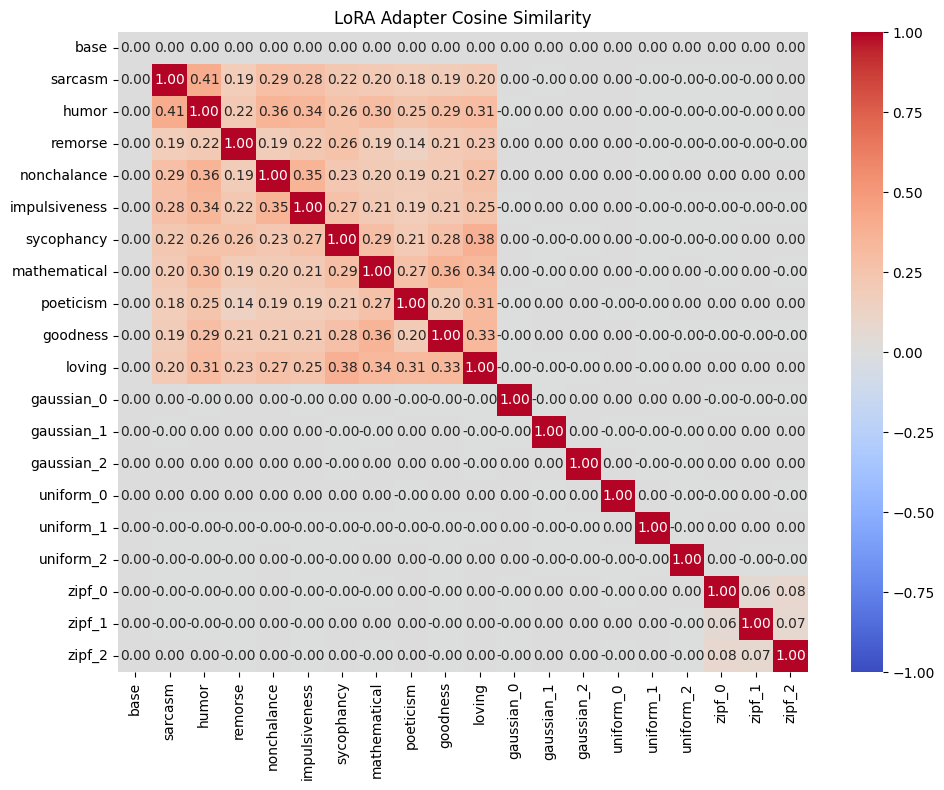

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()